# Mass Spectrometry Data Analysis Pipeline
## Comprehensive Signal Processing and Peak Detection Workflow

This notebook demonstrates a complete mass spectrometry (MS) data analysis pipeline using mzML files. It includes:
- **Data Ingestion**: Loading mzML files using pyOpenMS
- **Signal Processing**: Noise reduction and baseline correction
- **Peak Detection**: Identifying significant ions in mass spectra
- **Comparative Analysis**: Visualizing chemical fingerprints across samples

### Data Files
- Col_1.mzML - Sample 1
- Cytochrome_C.mzML - Sample 2
- T9_A1.mzML - Sample 3

In [2]:
# %%
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import minimum_filter
from pyopenms import MSExperiment, MzMLFile

# --- CONFIGURATION (The "Method File") ---
# DIRECTORY: Pointing exactly to where your files are in the screenshot
DATA_DIR = os.path.join("data", "mzML") 

# SIGNAL PROCESSING PARAMETERS
# SG_WINDOW: Small window (5) to preserve sharp peaks (prevents oversmoothing)
SG_WINDOW = 5        
SG_POLY_ORDER = 3    
# BASELINE_WIN: Size of the window to estimate the chemical noise floor
BASELINE_WIN = 50    
# PEAK THRESHOLDS: Adjusted for the intensities seen in your plots (>1000)
PEAK_HEIGHT = 1000   
PEAK_DIST = 5        

print(f"Target Data Directory: {os.path.abspath(DATA_DIR)}")
mzml_files = glob.glob(os.path.join(DATA_DIR, "*.mzML"))
print(f"Found {len(mzml_files)} files: {[os.path.basename(f) for f in mzml_files]}")

Target Data Directory: /home/ektedar/Documents/project/mass_spec_pipeline/mass_spec_pipeline/data/mzML
Found 3 files: ['Cytochrome_C.mzML', 'Col_1.mzML', 'T9_A1.mzML']


## Step 1: Setup and Configuration

Import necessary libraries and configure signal processing parameters. These parameters control how the raw mass spectrometry data will be processed:
- **Savitzky-Golay Filter**: Smooths noise while preserving sharp peaks
- **Baseline Correction**: Removes the chemical noise floor using morphological filtering
- **Peak Detection Thresholds**: Sets minimum intensity and distance criteria for identifying valid ions

In [3]:
# %%
class MassSpecPipeline:
    def __init__(self, filepath):
        self.filepath = filepath
        self.filename = os.path.basename(filepath)
        self.experiment = MSExperiment()
        
    def load_data(self):
        """Ingests the .mzML file using pyOpenMS"""
        try:
            MzMLFile().load(self.filepath, self.experiment)
            return True
        except Exception as e:
            print(f"Error loading {self.filename}: {e}")
            return False

    def get_spectrum_data(self, scan_index=0):
        """Extracts m/z and intensity arrays from a specific scan"""
        if self.experiment.getSize() <= scan_index:
            return None, None
        spectrum = self.experiment.getSpectrum(scan_index)
        mz, intensity = spectrum.get_peaks()
        return np.array(mz), np.array(intensity)

    def process_signal(self, intensity):
        """
        1. Noise Reduction (Savitzky-Golay)
        2. Baseline Correction (Morphological Minimum)
        """
        # Step 1: Smooth
        # standardizing negative values to 0
        smooth = savgol_filter(intensity, window_length=SG_WINDOW, polyorder=SG_POLY_ORDER)
        smooth = np.maximum(0, smooth) 
        
        # Step 2: Baseline Subtraction
        baseline = minimum_filter(smooth, size=BASELINE_WIN)
        corrected = smooth - baseline
        
        return smooth, corrected, baseline

    def find_peaks(self, mz, corrected_intensity):
        """Identifies peaks using scipy.signal"""
        indices, properties = find_peaks(
            corrected_intensity, 
            height=PEAK_HEIGHT, 
            distance=PEAK_DIST
        )
        return pd.DataFrame({
            "m/z": mz[indices],
            "Intensity": corrected_intensity[indices],
            "Index": indices,
            "Source": self.filename
        })

## Step 2: Core Pipeline Class

The `MassSpecPipeline` class encapsulates the complete analysis workflow:

1. **load_data()**: Reads mzML files using pyOpenMS
2. **get_spectrum_data()**: Extracts m/z and intensity arrays from individual scans
3. **process_signal()**: Applies noise reduction and baseline correction
4. **find_peaks()**: Identifies significant ions using peak detection algorithm

This modular design allows easy reuse across multiple files.

Visualizing Pipeline on: Cytochrome_C.mzML
Detected 3418 peaks in this scan.


Non-fatal error while loading 'data/mzML/Cytochrome_C.mzML': DateTime conversion error of "-infinity"


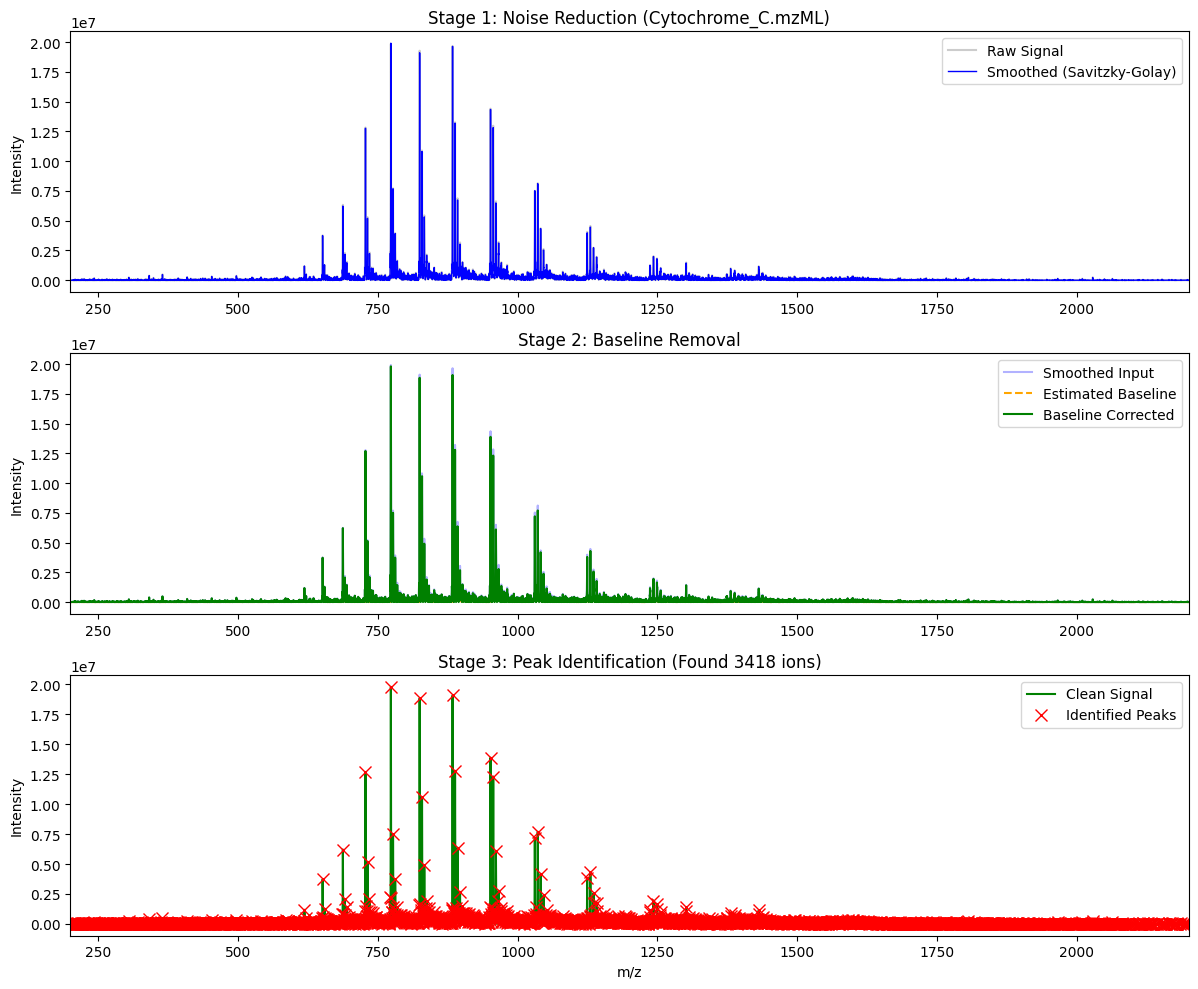

In [4]:
# %%
# Select a file to verify (using Cytochrome_C if available, else the first one)
target_file = next((f for f in mzml_files if "Cytochrome" in f), mzml_files[0])

print(f"Visualizing Pipeline on: {os.path.basename(target_file)}")

# 1. Initialize & Load
pipeline = MassSpecPipeline(target_file)
pipeline.load_data()

# 2. Get Data (Scan 0 usually has good data in these datasets)
raw_mz, raw_int = pipeline.get_spectrum_data(0)

# 3. Process
smooth_int, corrected_int, baseline = pipeline.process_signal(raw_int)

# 4. Pick Peaks
peaks_df = pipeline.find_peaks(raw_mz, corrected_int)
print(f"Detected {len(peaks_df)} peaks in this scan.")

# 5. PLOT
plt.figure(figsize=(12, 10))

# Subplot 1: Raw vs Smoothed
plt.subplot(3, 1, 1)
plt.plot(raw_mz, raw_int, color='#cccccc', label='Raw Signal')
plt.plot(raw_mz, smooth_int, color='blue', linewidth=1, label='Smoothed (Savitzky-Golay)')
plt.title(f"Stage 1: Noise Reduction ({os.path.basename(target_file)})")
plt.ylabel("Intensity")
plt.legend()
plt.xlim([raw_mz.min(), raw_mz.max()])

# Subplot 2: Baseline Correction
plt.subplot(3, 1, 2)
plt.plot(raw_mz, smooth_int, color='blue', alpha=0.3, label='Smoothed Input')
plt.plot(raw_mz, baseline, color='orange', linestyle='--', label='Estimated Baseline')
plt.plot(raw_mz, corrected_int, color='green', label='Baseline Corrected')
plt.title("Stage 2: Baseline Removal")
plt.ylabel("Intensity")
plt.legend()
plt.xlim([raw_mz.min(), raw_mz.max()])

# Subplot 3: Final Peak Detection
plt.subplot(3, 1, 3)
plt.plot(raw_mz, corrected_int, color='green', label='Clean Signal')
plt.plot(peaks_df['m/z'], peaks_df['Intensity'], "x", color='red', markersize=8, label='Identified Peaks')
plt.title(f"Stage 3: Peak Identification (Found {len(peaks_df)} ions)")
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.legend()
plt.xlim([raw_mz.min(), raw_mz.max()])

plt.tight_layout()
plt.show()

## Step 3: Visualization of Processing Pipeline

Here we demonstrate the complete signal processing workflow on a single file (Cytochrome C if available, otherwise the first file). The visualization shows:

1. **Top Panel**: Raw signal vs. Savitzky-Golay smoothing
2. **Middle Panel**: Baseline estimation and correction
3. **Bottom Panel**: Final cleaned signal with detected peaks marked in red

In [5]:
# %%
all_results = []

print("Starting Batch Processing...")
print("-" * 40)

for file_path in mzml_files:
    filename = os.path.basename(file_path)
    
    # Init Pipeline
    pipe = MassSpecPipeline(file_path)
    if not pipe.load_data():
        continue
        
    # Process First 10 Scans (For speed in demo)
    # In production, you would loop: range(pipe.experiment.getSize())
    scan_limit = min(10, pipe.experiment.getSize())
    
    print(f"Processing {filename}: Analyzing first {scan_limit} scans...")
    
    for i in range(scan_limit):
        mz, intensity = pipe.get_spectrum_data(i)
        _, corrected, _ = pipe.process_signal(intensity)
        
        # Peak Pick
        peaks = pipe.find_peaks(mz, corrected)
        
        if not peaks.empty:
            peaks['Scan_ID'] = i
            all_results.append(peaks)

# Compile Results
if all_results:
    final_df = pd.concat(all_results)
    print("-" * 40)
    print(f"Batch Complete. Total Peaks Found: {len(final_df)}")
    display(final_df.head())
else:
    print("No peaks found in any files.")

Starting Batch Processing...
----------------------------------------
Processing Cytochrome_C.mzML: Analyzing first 10 scans...
Processing Col_1.mzML: Analyzing first 10 scans...
Processing T9_A1.mzML: Analyzing first 10 scans...
----------------------------------------
Batch Complete. Total Peaks Found: 35433


,m/z,Intensity,Index,Source,Scan_ID
0,200.1875,3430.542969,3,Cytochrome_C.mzML,0
1,201.5625,15485.885742,25,Cytochrome_C.mzML,0
2,202.0000,3178.657227,32,Cytochrome_C.mzML,0
3,202.8750,5690.600098,46,Cytochrome_C.mzML,0
4,204.1250,6175.914062,66,Cytochrome_C.mzML,0


## Step 4: Batch Processing

Process all available mzML files in the data directory. For each file:
- Process the first 10 scans (for demonstration; production use would process all scans)
- Extract peaks from each scan
- Combine results into a unified DataFrame for downstream analysis

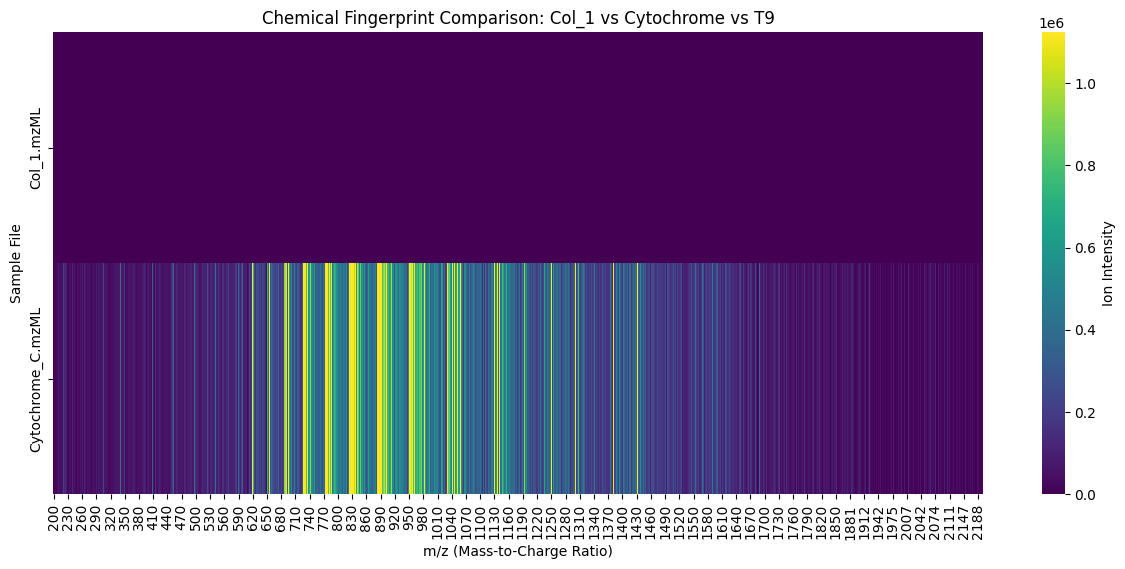

In [6]:
# %%
# Prepare data for Heatmap
# We bin the mass values (round to nearest integer) to align them across files
final_df['mz_bin'] = final_df['m/z'].round(0).astype(int)

# Create Pivot Table: Rows=File, Cols=Mass, Values=Intensity
heatmap_data = final_df.pivot_table(
    index='Source', 
    columns='mz_bin', 
    values='Intensity', 
    aggfunc='max'
).fillna(0)

# Plot
plt.figure(figsize=(15, 6))
sns.heatmap(
    heatmap_data, 
    cmap="viridis", 
    robust=True, # Handles outliers better
    cbar_kws={'label': 'Ion Intensity'}
)
plt.title("Chemical Fingerprint Comparison: Col_1 vs Cytochrome vs T9")
plt.xlabel("m/z (Mass-to-Charge Ratio)")
plt.ylabel("Sample File")
plt.show()

## Step 5: Comparative Analysis - Chemical Fingerprinting

Create a heatmap showing the chemical composition across all samples. Each row represents a sample file, columns represent m/z values (binned to integers), and colors represent ion intensity. This visualization:
- Reveals unique chemical signatures in each sample
- Identifies common ions across samples
- Highlights sample-specific markers